<a href="https://colab.research.google.com/github/fathanick/Fundamentals-of-Data-Science/blob/main/Support%20Vector%20Machine/svm_sentiment_analysis_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Sentiment Analysis Tutorial using Support Vector Machine (SVM)
This tutorial demonstrates how to build and evaluate a text classification model using a Support Vector Machine (SVM) classifier in Python and Google Colab. We will classify movie/tweet reviews as either **Positive** or **Negative**.

## Step 1: Import Needed Libraries
We import foundational libraries for data science, natural language processing (NLP), and machine learning pipelines.

In [1]:
# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing (NLP)
import string
import nltk
from nltk.corpus import stopwords

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download text processing packages
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Step 2: Data Loading
We pull a streamlined public sentiment dataset containing text strings along with their matching sentiment labels.

In [2]:
# Load the sentiment analysis dataset
url = "https://raw.githubusercontent.com/TharinduMunasinge/Twitter-Sentiment-Analysis/master/DataSet/FinalizedFull.csv"
df = pd.read_csv(url)

# Clean up schema mapping for consistency:
# The raw column names are 'tweet' and 'senti' (0 = negative, 4 = positive)
df = df.rename(columns={'tweet': 'review', 'senti': 'sentiment'})

# Map numeric classifications to simpler explicit labels (0: Negative, 1: Positive)
df['sentiment'] = df['sentiment'].replace({0: 0, 4: 1, 2: 1})

# Display first few entries
df.head()

,review,sentiment
0,@united UA5396 can wait for me. I'm on the gro...,0
1,I hate Time Warner! Soooo wish I had Vios. Can...,0
2,"@united Oh, we are sure it's not planned, but ...",0
3,Tom Shanahan's latest column on SDSU and its N...,1
4,Found the self driving car!! /IWo3QSvdu2,1


/tmp/ipykernel_1625/3511173892.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


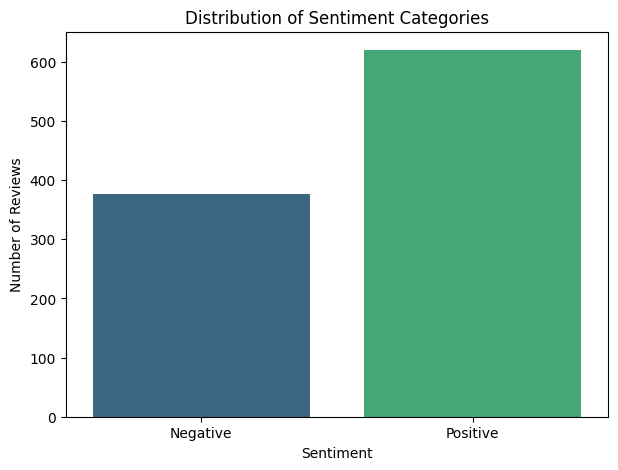

In [3]:
sentiment_counts = df['sentiment'].value_counts().sort_index()
sentiment_labels = {0: 'Negative', 1: 'Positive'}

plt.figure(figsize=(7, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.xticks(ticks=[0, 1], labels=[sentiment_labels[0], sentiment_labels[1]])
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

## Step 3: Data Preprocessing
Raw text data contains noise like punctuation and boilerplate filler words (stopwords). We clean this up to help the model learn more efficiently.

In [4]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Strip punctuation characters
    clean_text = "".join([char for char in text if char not in string.punctuation])
    # Lowercase text transformation and eliminate empty stopwords
    stop_words = set(stopwords.words('english'))
    words = [word.lower() for word in clean_text.split() if word.lower() not in stop_words]
    return " ".join(words)

# Apply formatting transformation onto dataset
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Drop any blank rows resulting from cleaning routines
df = df[df['cleaned_review'] != ""]
df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,@united UA5396 can wait for me. I'm on the gro...,united ua5396 wait im ground trying get gate m...
1,I hate Time Warner! Soooo wish I had Vios. Can...,hate time warner soooo wish vios cant watch fr...
2,"@united Oh, we are sure it's not planned, but ...",united oh sure planned occurs absolutely consi...
3,Tom Shanahan's latest column on SDSU and its N...,tom shanahans latest column sdsu ncaa baseball...
4,Found the self driving car!! /IWo3QSvdu2,found self driving car iwo3qsvdu2


## Step 4: Feature Extraction (Vectorization)
Machine learning algorithms require numbers, not strings. We convert our processed text sentences into numerical matrices using standard TF-IDF scaling methods.

In [5]:
# Initialize TF-IDF Vectorizer metric mapping
tfidf = TfidfVectorizer(max_features=2500)

# Build feature extraction vectors (X) and label indices (y)
X = tfidf.fit_transform(df['cleaned_review'])
y = df['sentiment'].values
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (997, 2500)


## Step 5: Data Splitting
We segment our extracted feature vectors into 80% training instances and 20% validation instances to guarantee unbiased metric evaluation.

In [6]:
# Execute deterministic dataset partition
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training feature dimension matrix space: {X_train.shape}")
print(f"Evaluation testing feature dimension space: {X_test.shape}")

Training feature dimension matrix space: (797, 2500)
Evaluation testing feature dimension space: (200, 2500)


## Step 6: Classification (Model Training)
We instantiate a Support Vector Classifier (`SVC`) with a **linear kernel** and fit it directly to our sparse text numerical arrays.

In [7]:
# Initialize linear kernel Support Vector Classifier (SVC)
svm_model = SVC(kernel='linear', random_state=42)

# Fit classifier onto training data matrix
svm_model.fit(X_train, y_train)
print("Linear SVM Sentiment Classifier trained successfully!")

Linear SVM Sentiment Classifier trained successfully!


## Step 7: Evaluation
We measure the performance of our model on unseen test observations by generating an accuracy score, a classification report, and a confusion matrix heatmap.

Accuracy Score: 82.50%

Classification Report Matrix details:
              precision    recall  f1-score   support

    Negative       0.86      0.64      0.74        76
    Positive       0.81      0.94      0.87       124

    accuracy                           0.82       200
   macro avg       0.84      0.79      0.80       200
weighted avg       0.83      0.82      0.82       200



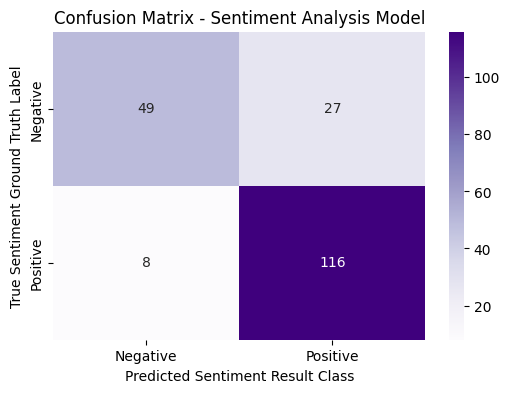

In [8]:
# Compute model predictions using the test dataset array
y_pred = svm_model.predict(X_test)

# Report summary diagnostic data metrics
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report Matrix details:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Build confusion index data
cm = confusion_matrix(y_test, y_pred)

# Plot interactive evaluation heatmap layout
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Sentiment Analysis Model')
plt.xlabel('Predicted Sentiment Result Class')
plt.ylabel('True Sentiment Ground Truth Label')
plt.show()

## Step 8: Inference (Interactive Input Dashboard)
Run this block to launch an interactive widget panel. It uses `ipywidgets` to enable dynamic real-time prediction triggers via clear UI control buttons.

In [9]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Instantiate dashboard text area space elements
text_input = widgets.Textarea(
    value='',
    placeholder='Type your review message here...',
    description='Review Text:',
    layout=widgets.Layout(width='85%', height='100px')
)

submit_button = widgets.Button(description='Analyze Sentiment', button_style='success')
clear_button = widgets.Button(description='Clear Input', button_style='warning')
output_area = widgets.Output()

# Handle algorithmic deduction pipeline calculations
def on_submit_clicked(b):
    with output_area:
        clear_output()
        raw_input = text_input.value

        if not raw_input or raw_input.strip() == "":
            print("❌ Input contains no characters. Please input valid text.")
            return

        # Transform data variables downstream
        clean_input = preprocess_text(raw_input)
        vectorized_input = tfidf.transform([clean_input])

        # Predict
        prediction = svm_model.predict(vectorized_input)[0]
        sentiment_result = "POSITIVE" if prediction == 1 else "NEGATIVE"
        emoji_flag = "👍" if prediction == 1 else "👎"

        print(f"🔮 Predicted Sentiment: **{sentiment_result}** {emoji_flag}")

# Clear standard pipeline fields
def on_clear_clicked(b):
    text_input.value = ''
    with output_area:
        clear_output()

# Bind operational event hooks to buttons
submit_button.on_click(on_submit_clicked)
clear_button.on_click(on_clear_clicked)

# Render complete system pipeline setup
button_layout = widgets.HBox([submit_button, clear_button])
display(text_input, button_layout, output_area)

Textarea(value='', description='Review Text:', layout=Layout(height='100px', width='85%'), placeholder='Type y…

Output()